In [ ]:
import pandas as pd
import numpy as np
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_excel("neiss2024.xlsx")

In [ ]:
text_cols = [
    "Diagnosis",
    "Other_Diagnosis",
    "Diagnosis_2",
    "Other_Diagnosis_2",
    "Narrative_1"
]
for col in text_cols:
    df[col] = df[col].fillna("").astype(str)

df["combined_text"] = df[text_cols].agg(" ".join, axis=1).str.lower()

In [ ]:
cvd_patterns = [
    r"\bhypertension\b", r"\bhtn\b", r"\bhigh blood pressure\b",
    r"\bcoronary artery disease\b", r"\bcad\b", r"\bangina\b",
    r"\bmi\b", r"\bmyocardial infarction\b", r"\bcabg\b", r"\bstent\b",
    r"\bischemic heart disease\b",
    r"\bheart failure\b", r"\bchf\b",
    r"\bafib\b", r"\ba[- ]fib\b", r"\batrial fibrillation\b",
    r"\barrhythmia\b",
    r"\bstroke\b", r"\btia\b", r"\bcva\b",
    r"\bpvd\b", r"\bpad\b",
    r"\bcardiomyopathy\b",
    r"\bvalvular\b", r"\baortic stenosis\b"
]

In [ ]:
pattern = re.compile("|".join(cvd_patterns), flags=re.IGNORECASE)
neg_words = r"(no|denies|denied|without|negative for)"

def has_cvd(text):
    matches = list(pattern.finditer(text))
    if not matches:
        return 0

    for m in matches:
        context = text[max(0, m.start()-20):m.start()]
        if not re.search(neg_words, context, flags=re.IGNORECASE):
            return 1
    return 0

df["CVD"] = df["combined_text"].apply(has_cvd)

print(df["CVD"].value_counts())
print(df[df["CVD"] == 1][["Narrative_1"]].head(5))

df.to_excel("step1_cvd_done.xlsx", index=False)
print("Saved: step1_cvd_done.xlsx")

CVD
0    358912
1      2760
Name: count, dtype: int64
                                           Narrative_1
203  68YOM, HISTORY OF HEART FAILURE, TODAY WAS SIT...
358  89YOM, FELL OUT OF BED AND FOUND DOWN ON THE F...
434  62YOM TO ER FOR LOWER BACK PAIN ONSET SUNDAY, ...
668  75YOF BROUGHT IN BY AIR FROM HOME AFTER BEING ...
760  91YOF, FOUND DOWN IN FLOOR AFTER FALL, C/O LOW...
Saved: step1_cvd_done.xlsx


In [ ]:
import re
import pandas as pd

cvd_patterns = [
    r"\bhypertension\b", r"\bhtn\b", r"\bhigh blood pressure\b",
    r"\bcoronary artery disease\b", r"\bcad\b", r"\bangina\b",
    r"\bmyocardial infarction\b", r"\bmi\b", r"\bcabg\b", r"\bstent\b",
    r"\bischemic heart disease\b",
    r"\bheart failure\b", r"\bchf\b",
    r"\batrial fibrillation\b", r"\bafib\b", r"\ba[- ]fib\b",
    r"\barrhythmia\b",
    r"\bstroke\b", r"\btia\b", r"\bcva\b",
    r"\bpvd\b", r"\bpad\b",
    r"\bcardiomyopathy\b",
    r"\bvalvular\b", r"\baortic stenosis\b"
]

negation_terms = ["no", "denies", "denied", "without", "negative for"]

cvd_regex = re.compile("|".join(cvd_patterns), flags=re.IGNORECASE)

def rule_label_with_window(text, window=20):
    if pd.isna(text):
        return 0
    text = str(text).lower()
    for match in cvd_regex.finditer(text):
        start = match.start()
        left_context = text[max(0, start - window):start]
        if not any(neg in left_context for neg in negation_terms):
            return 1
    return 0


for w in [10, 20, 30, 40]:
    col = f'cvd_rule_w{w}'
    df[col] = df['combined_text'].apply(lambda x: rule_label_with_window(x, window=w))
    print(w, df[col].sum(), df[col].mean())

10 2866 0.007924307106991971
20 2760 0.007631223871353049
30 2679 0.007407264040345949
40 2600 0.007188834081709394


In [ ]:
print(df["Disposition"].value_counts(dropna=False).sort_index())

Disposition
1    308446
2      4106
4     38146
5      3008
6      7669
8       294
9         3
Name: count, dtype: int64


In [ ]:
def map_admission(disposition):
    if disposition == 1:
        return 0
    elif disposition in [2, 4, 5]:
        return 1
    else:
        return np.nan

df["Admission"] = df["Disposition"].apply(map_admission)

print(df["Admission"].value_counts(dropna=False))

analysis_df = df[df["Admission"].notna()].copy()

print("Analysis sample size:", len(analysis_df))
print(analysis_df["Admission"].value_counts())

analysis_df.to_excel("step2_analysis_ready.xlsx", index=False)
print("Saved: step2_analysis_ready.xlsx")

Admission
0.0    308446
1.0     45260
NaN      7966
Name: count, dtype: int64
Analysis sample size: 353706
Admission
0.0    308446
1.0     45260
Name: count, dtype: int64
Saved: step2_analysis_ready.xlsx


In [ ]:
print(analysis_df["Sex"].value_counts(dropna=False).sort_index())

Sex
0       344
1    193274
2    160088
Name: count, dtype: int64


In [ ]:
analysis_df["Sex"] = analysis_df["Sex"].replace({3: np.nan})

analysis_df["Sex_binary"] = analysis_df["Sex"].apply(lambda x: 1 if x == 1 else 0)

print(analysis_df["Sex_binary"].value_counts(dropna=False))

Sex_binary
1    193274
0    160432
Name: count, dtype: int64


In [ ]:
analysis_df = analysis_df[analysis_df["Age"] > 0]

In [ ]:
import statsmodels.api as sm
X = analysis_df[["CVD", "Age", "Sex_binary"]]
y = analysis_df["Admission"]
X = sm.add_constant(X)


model = sm.Logit(y, X).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.371196
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              Admission   No. Observations:               353685
Model:                          Logit   Df Residuals:                   353681
Method:                           MLE   Df Model:                            3
Date:                Tue, 07 Apr 2026   Pseudo R-squ.:                 0.02938
Time:                        01:07:23   Log-Likelihood:            -1.3129e+05
converged:                       True   LL-Null:                   -1.3526e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2519      0.009   -244.831      0.000      -2.270      -2.234
CVD            2.1420      0.

In [ ]:
params = model.params
conf = model.conf_int()

odds_ratios = np.exp(params)
conf["OR_lower"] = np.exp(conf[0])
conf["OR_upper"] = np.exp(conf[1])

results_table = pd.DataFrame({
    "Odds Ratio": odds_ratios,
    "CI Lower": conf["OR_lower"],
    "CI Upper": conf["OR_upper"],
    "p-value": model.pvalues
})

print(results_table)

results_table.to_excel("table2_regression_results.xlsx")

            Odds Ratio  CI Lower  CI Upper       p-value
const         0.105204  0.103325  0.107118  0.000000e+00
CVD           8.516692  7.886937  9.196731  0.000000e+00
Age           1.006167  1.006000  1.006333  0.000000e+00
Sex_binary    0.947989  0.929127  0.967233  1.897974e-07


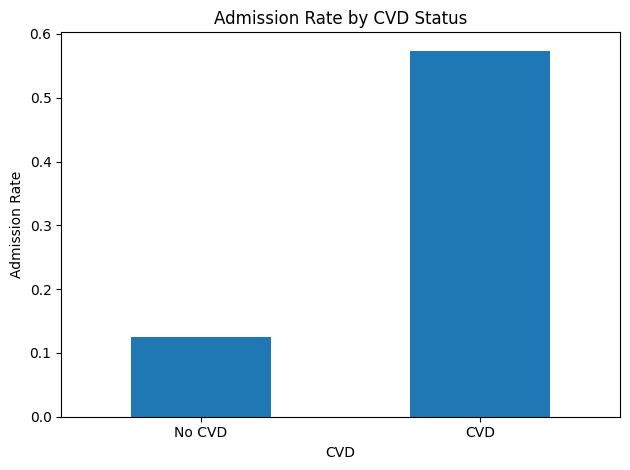

In [ ]:
plot_df = analysis_df.groupby("CVD")["Admission"].mean()

plot_df.plot(kind="bar")
plt.xticks([0,1], ["No CVD", "CVD"], rotation=0)
plt.ylabel("Admission Rate")
plt.title("Admission Rate by CVD Status")

plt.tight_layout()
plt.savefig("figure1_admission.png")
plt.show()

In [ ]:
table1 = analysis_df.groupby("CVD").agg({
    "Age": ["mean", "std"],
    "Sex_binary": "mean",
    "Admission": "mean"
})

table1.columns = ["Age_mean", "Age_std", "Male_%", "Admission_rate"]

table1["Male_%"] = table1["Male_%"] * 100
table1["Admission_rate"] = table1["Admission_rate"] * 100

print(table1)

table1.to_excel("table1_descriptive.xlsx")

      Age_mean    Age_std     Male_%  Admission_rate
CVD                                                 
0    47.391674  50.216854  54.657898       12.447181
1    71.044085  21.097007  52.498163       57.384276


In [ ]:
counts = analysis_df["CVD"].value_counts()

table1["N"] = counts
print(table1)

      Age_mean    Age_std     Male_%  Admission_rate       N
CVD                                                         
0    47.391674  50.216854  54.657898       12.447181  350963
1    71.044085  21.097007  52.498163       57.384276    2722


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, chi2_contingency, fisher_exact


desc_df = analysis_df[analysis_df['Age'] > 0].copy()


group_col = "CVD"


def bootstrap_ci_proportion(x, n_bootstrap=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    x = np.asarray(x, dtype=float)
    n = len(x)
    stats = []
    for _ in range(n_bootstrap):
        sample = rng.choice(x, size=n, replace=True)
        stats.append(np.mean(sample))
    return (np.mean(x), np.percentile(stats, 2.5), np.percentile(stats, 97.5))

def format_pct_ci(point, low, high):
    return f"{point*100:.1f}% ({low*100:.1f}–{high*100:.1f})"

def format_p(p):
    return "<0.001" if p < 0.001 else f"{p:.3f}"

def categorical_pvalue(group_col, binary_col, df):
    tbl = pd.crosstab(df[group_col], df[binary_col])
    if tbl.shape == (2, 2):
        chi2, p_chi, dof, expected = chi2_contingency(tbl)
        if (expected < 5).any():
            _, p = fisher_exact(tbl.values)
            return p
        return p_chi
    else:
        _, p, _, _ = chi2_contingency(tbl)
        return p


rows = []
for group_value, group_name in [(0, "No CVD"), (1, "CVD")]:
    g = desc_df[desc_df[group_col] == group_value].copy()
    n = len(g)
    age_mean = g["Age"].mean()
    age_sd = g["Age"].std()

    male_point, male_low, male_high = bootstrap_ci_proportion(g["Sex_binary"])
    adm_point, adm_low, adm_high = bootstrap_ci_proportion(g["Admission"])

    rows.append({
        "CVD group": group_name,
        "N": n,
        "Age mean": f"{age_mean:.2f}",
        "Age SD": f"{age_sd:.2f}",
        "Male % (95% CI)": format_pct_ci(male_point, male_low, male_high),
        "Admission rate % (95% CI)": format_pct_ci(adm_point, adm_low, adm_high)
    })


age_no = desc_df.loc[desc_df[group_col] == 0, "Age"]
age_yes = desc_df.loc[desc_df[group_col] == 1, "Age"]
_, p_age = ttest_ind(age_no, age_yes, equal_var=False, nan_policy="omit")

p_male = categorical_pvalue(group_col, "Sex_binary", desc_df)
p_adm = categorical_pvalue(group_col, "Admission", desc_df)

rows.append({
    "CVD group": "P-value",
    "N": "",
    "Age mean": format_p(p_age),
    "Age SD": "",
    "Male % (95% CI)": format_p(p_male),
    "Admission rate % (95% CI)": format_p(p_adm)
})

descriptive_table = pd.DataFrame(rows)
print(descriptive_table)
descriptive_table.to_excel("table_descriptive_rule_cvd_bootstrap.xlsx", index=False)

  CVD group       N Age mean Age SD    Male % (95% CI)  \
0    No CVD  350963    47.39  50.22  54.7% (54.5–54.8)   
1       CVD    2722    71.04  21.10  52.5% (50.6–54.4)   
2   P-value           <0.001                     0.025   

  Admission rate % (95% CI)  
0         12.4% (12.3–12.6)  
1         57.4% (55.5–59.1)  
2                    <0.001  


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact


desc_df = analysis_df[analysis_df['Age'] > 0][['CVD', 'Age', 'Sex_binary', 'Admission']].dropna().copy()


def bootstrap_ci_proportion(x, n_bootstrap=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    x = np.asarray(x, dtype=float)
    n = len(x)
    stats = []
    for _ in range(n_bootstrap):
        sample = rng.choice(x, size=n, replace=True)
        stats.append(np.mean(sample))
    return (np.mean(x), np.percentile(stats, 2.5), np.percentile(stats, 97.5))

def format_pct_ci(point, low, high):
    return f"{point*100:.1f}% ({low*100:.1f}–{high*100:.1f})"

def format_p(p):
    return "<0.001" if p < 0.001 else f"{p:.3f}"

def categorical_pvalue(group_col, binary_col, df):
    tbl = pd.crosstab(df[group_col], df[binary_col])
    if tbl.shape == (2, 2):
        chi2, p_chi, dof, expected = chi2_contingency(tbl)
        if (expected < 5).any():
            _, p = fisher_exact(tbl.values)
            return p
        return p_chi
    else:
        _, p, _, _ = chi2_contingency(tbl)
        return p

rows = []
for group_value, group_name in [(0, "No CVD"), (1, "CVD")]:
    g = desc_df[desc_df["CVD"] == group_value].copy()
    n = len(g)


    age_med = g["Age"].median()
    age_q1 = g["Age"].quantile(0.25)
    age_q3 = g["Age"].quantile(0.75)

    male_point, male_low, male_high = bootstrap_ci_proportion(g["Sex_binary"])
    adm_point, adm_low, adm_high = bootstrap_ci_proportion(g["Admission"])

    rows.append({
        "CVD group": group_name,
        "N": n,
        "Age, median (IQR)": f"{age_med:.1f} ({age_q1:.1f}–{age_q3:.1f})",
        "Male, % (95% CI)": format_pct_ci(male_point, male_low, male_high),
        "Admission rate, % (95% CI)": format_pct_ci(adm_point, adm_low, adm_high)
    })


age_no = desc_df.loc[desc_df["CVD"] == 0, "Age"]
age_yes = desc_df.loc[desc_df["CVD"] == 1, "Age"]
_, p_age = mannwhitneyu(age_no, age_yes, alternative="two-sided")

p_male = categorical_pvalue("CVD", "Sex_binary", desc_df)
p_adm = categorical_pvalue("CVD", "Admission", desc_df)

rows.append({
    "CVD group": "P-value",
    "N": "",
    "Age, median (IQR)": format_p(p_age),
    "Male, % (95% CI)": format_p(p_male),
    "Admission rate, % (95% CI)": format_p(p_adm)
})

descriptive_table = pd.DataFrame(rows)
print(descriptive_table)
descriptive_table.to_excel("table_descriptive_rule_cvd_bootstrap_v2.xlsx", index=False)

  CVD group       N Age, median (IQR)   Male, % (95% CI)  \
0    No CVD  350963  33.0 (13.0–67.0)  54.7% (54.5–54.8)   
1       CVD    2722  75.0 (63.0–84.0)  52.5% (50.6–54.4)   
2   P-value                    <0.001              0.025   

  Admission rate, % (95% CI)  
0          12.4% (12.3–12.6)  
1          57.4% (55.5–59.1)  
2                     <0.001  


**Tfidf + Logistic regression**

In [ ]:
text_cols = [
    "Diagnosis",
    "Other_Diagnosis",
    "Diagnosis_2",
    "Other_Diagnosis_2",
    "Narrative_1"
]

for col in text_cols:
    df[col] = df[col].fillna("").astype(str)

df["combined_text"] = df[text_cols].agg(" ".join, axis=1).str.lower()

print(df["combined_text"].head())

0    64    16yom playing soccer, hurt his shoulder....
1    59    56yof was cutting up cabbage and knife s...
2    54    10 yom c/o crush injury of toe s/p ridin...
3    41    3 yof presents with swallowed foreign bo...
4    59    2 yom presents with facial laceration s/...
Name: combined_text, dtype: object


In [ ]:
cvd_patterns = [
    r"\bhypertension\b", r"\bhtn\b", r"\bhigh blood pressure\b",
    r"\bcoronary artery disease\b", r"\bcad\b", r"\bangina\b",
    r"\bmi\b", r"\bmyocardial infarction\b", r"\bcabg\b", r"\bstent\b",
    r"\bischemic heart disease\b",
    r"\bheart failure\b", r"\bchf\b",
    r"\bafib\b", r"\ba[- ]fib\b", r"\batrial fibrillation\b",
    r"\barrhythmia\b",
    r"\bstroke\b", r"\btia\b", r"\bcva\b",
    r"\bpvd\b", r"\bpad\b",
    r"\bcardiomyopathy\b",
    r"\bvalvular\b", r"\baortic stenosis\b"
]

pattern = re.compile("|".join(cvd_patterns), flags=re.IGNORECASE)
neg_words = r"(no|denies|denied|without|negative for)"

def has_cvd(text):
    matches = list(pattern.finditer(text))
    if not matches:
        return 0
    for m in matches:
        context = text[max(0, m.start()-20):m.start()]
        if not re.search(neg_words, context, flags=re.IGNORECASE):
            return 1
    return 0

df["CVD_rule"] = df["combined_text"].apply(has_cvd)

print(df["CVD_rule"].value_counts())

CVD_rule
0    358912
1      2760
Name: count, dtype: int64


In [ ]:
df_model = df[df["combined_text"].str.strip() != ""].copy()

print(df_model.shape)
print(df_model["CVD_rule"].value_counts())

(361672, 33)
CVD_rule
0    358912
1      2760
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X = df_model["combined_text"]
y = df_model["CVD_rule"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(289337,) (72335,)


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "auroc": "roc_auc"
}

lr_cv_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        max_features=20000,
        min_df=2
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

svm_cv_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        max_features=20000,
        min_df=2
    )),
    ("clf", CalibratedClassifierCV(
        estimator=LinearSVC(
            class_weight="balanced",
            random_state=42
        ),
        method="sigmoid",
        cv=5
    ))
])


lr_cv_scores = cross_validate(
    lr_cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

svm_cv_scores = cross_validate(
    svm_cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

def summarize_cv_scores(name, scores_dict):
    return {
        "Model": name,
        "Precision_mean": np.mean(scores_dict["test_precision"]),
        "Precision_sd": np.std(scores_dict["test_precision"], ddof=1),
        "Recall_mean": np.mean(scores_dict["test_recall"]),
        "Recall_sd": np.std(scores_dict["test_recall"], ddof=1),
        "F1_mean": np.mean(scores_dict["test_f1"]),
        "F1_sd": np.std(scores_dict["test_f1"], ddof=1),
        "AUROC_mean": np.mean(scores_dict["test_auroc"]),
        "AUROC_sd": np.std(scores_dict["test_auroc"], ddof=1),
    }

cv_summary = pd.DataFrame([
    summarize_cv_scores("TF-IDF + Logistic Regression", lr_cv_scores),
    summarize_cv_scores("TF-IDF + Linear SVM", svm_cv_scores)
])

print(cv_summary)
cv_summary.to_excel("table_cv_text_classifiers.xlsx", index=False)

                          Model  Precision_mean  Precision_sd  Recall_mean  \
0  TF-IDF + Logistic Regression        0.814030      0.011075     0.966488   
1           TF-IDF + Linear SVM        0.958159      0.009356     0.930707   

   Recall_sd   F1_mean     F1_sd  AUROC_mean  AUROC_sd  
0   0.008059  0.883676  0.006373    0.997778  0.001512  
1   0.011612  0.944162  0.005305    0.997166  0.001912  


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    max_features=20000,
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(289337, 20000)
(72335, 20000)


In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

clf.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = clf.predict(X_test_tfidf)
y_prob = clf.predict_proba(X_test_tfidf)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("AUROC:", roc_auc_score(y_test, y_prob))

[[71689    94]
 [   10   542]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71783
           1       0.85      0.98      0.91       552

    accuracy                           1.00     72335
   macro avg       0.93      0.99      0.96     72335
weighted avg       1.00      1.00      1.00     72335

AUROC: 0.9996400181141755


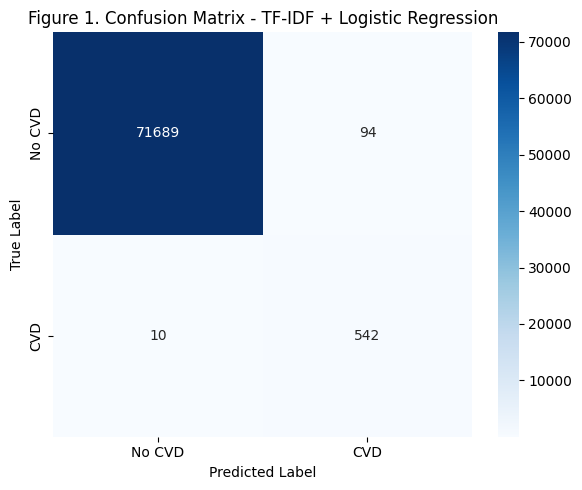

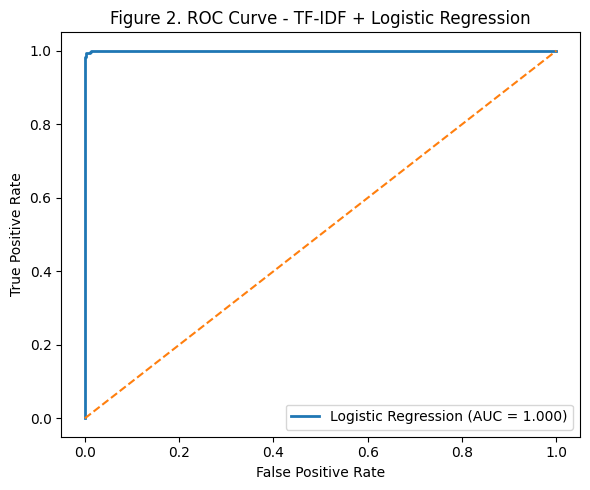

In [ ]:
cm_log = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No CVD", "CVD"],
            yticklabels=["No CVD", "CVD"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Figure 1. Confusion Matrix - TF-IDF + Logistic Regression")
plt.tight_layout()
plt.savefig("figure1_confusion_logistic.png", dpi=300, bbox_inches="tight")
plt.show()


fpr_log, tpr_log, _ = roc_curve(y_test, y_prob)
auc_log = auc(fpr_log, tpr_log)

plt.figure(figsize=(6, 5))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Figure 2. ROC Curve - TF-IDF + Logistic Regression")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figure2_roc_logistic.png", dpi=300, bbox_inches="tight")
plt.show()

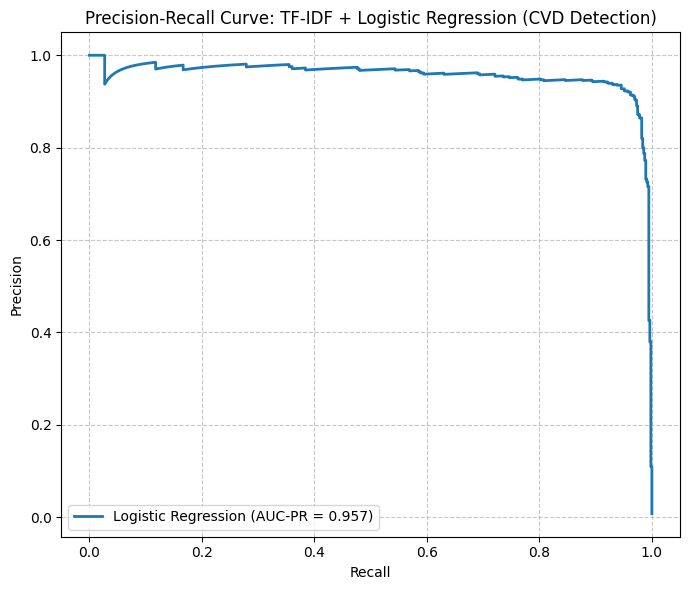

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt


precision_log, recall_log, _ = precision_recall_curve(y_test, y_prob)
auc_pr_log = auc(recall_log, precision_log)

plt.figure(figsize=(7, 6))
plt.plot(recall_log, precision_log, label=f'Logistic Regression (AUC-PR = {auc_pr_log:.3f})', color='tab:blue', linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: TF-IDF + Logistic Regression (CVD Detection)')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('figure_pr_curve_logistic.png', dpi=300, bbox_inches='tight')
plt.show()

Note: y_prob_svm not found. Please run the SVM training cell (1--rhwC_H-4_) to include it in the plot.


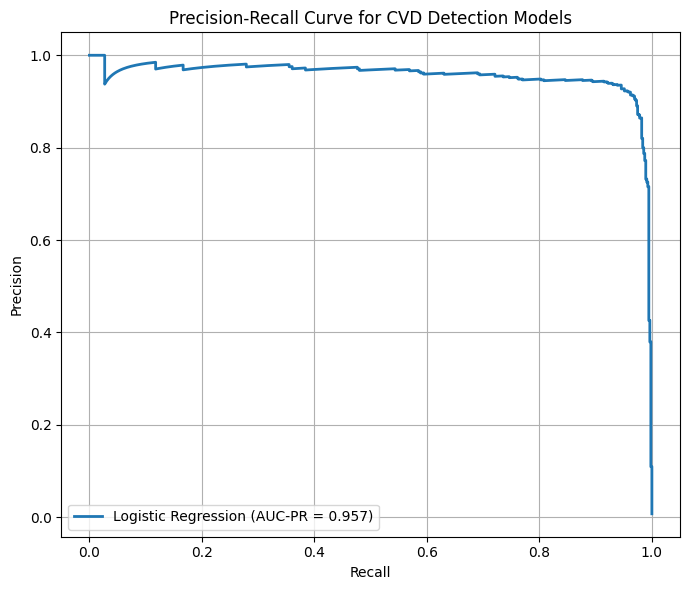

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt


try:

    precision_log, recall_log, _ = precision_recall_curve(y_test, y_prob)
    auc_pr_log = auc(recall_log, precision_log)

    plt.figure(figsize=(7, 6))
    plt.plot(recall_log, precision_log, label=f'Logistic Regression (AUC-PR = {auc_pr_log:.3f})', linewidth=2)

    if 'y_prob_svm' in globals():
        precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_prob_svm)
        auc_pr_svm = auc(recall_svm, precision_svm)
        plt.plot(recall_svm, precision_svm, label=f'Linear SVM (AUC-PR = {auc_pr_svm:.3f})', linewidth=2)
    else:
        print("Note: y_prob_svm not found. Please run the SVM training cell (1--rhwC_H-4_) to include it in the plot.")

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve for CVD Detection Models')
    plt.legend(loc='lower left')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('figure_pr_curve_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
except NameError as e:
    print(f"Error: {e}. Please ensure all model training cells have been executed.")

In [ ]:
X_all_tfidf = tfidf.transform(df["combined_text"])
df["CVD_ml_prob"] = clf.predict_proba(X_all_tfidf)[:, 1]
df["CVD_ml"] = (df["CVD_ml_prob"] >= 0.5).astype(int)

print(df["CVD_ml"].value_counts())

CVD_ml
0    358448
1      3224
Name: count, dtype: int64


In [ ]:
def map_admission(disposition):
    if disposition == 1:
        return 0
    elif disposition in [2, 4, 5]:
        return 1
    else:
        return np.nan

df["Admission"] = df["Disposition"].apply(map_admission)

analysis_df = df[df["Admission"].notna()].copy()
analysis_df = analysis_df[analysis_df["Age"] > 0].copy()

print(analysis_df["Admission"].value_counts(dropna=False))

Admission
0.0    308438
1.0     45247
Name: count, dtype: int64


In [ ]:
analysis_df["Sex"] = analysis_df["Sex"].replace({3: np.nan})
analysis_df = analysis_df[analysis_df["Sex"].isin([1, 2])].copy()

analysis_df["Sex_binary"] = analysis_df["Sex"].apply(lambda x: 1 if x == 1 else 0)

print(analysis_df["Sex_binary"].value_counts())

Sex_binary
1    193258
0    160084
Name: count, dtype: int64


In [ ]:
import statsmodels.api as sm

X = analysis_df[["CVD_ml", "Age", "Sex_binary"]]
y = analysis_df["Admission"]

X = sm.add_constant(X)

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.370278
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              Admission   No. Observations:               353342
Model:                          Logit   Df Residuals:                   353338
Method:                           MLE   Df Model:                            3
Date:                Tue, 07 Apr 2026   Pseudo R-squ.:                 0.03199
Time:                        01:16:36   Log-Likelihood:            -1.3083e+05
converged:                       True   LL-Null:                   -1.3516e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2559      0.009   -244.600      0.000      -2.274      -2.238
CVD_ml         2.2234      0.

In [ ]:
table1 = analysis_df.groupby("CVD_ml").agg({
    "Age": ["mean", "std"],
    "Sex_binary": "mean",
    "Admission": "mean"
})

table1.columns = ["Age_mean", "Age_std", "Male_%", "Admission_rate"]
table1["Male_%"] = table1["Male_%"] * 100
table1["Admission_rate"] = table1["Admission_rate"] * 100
table1["N"] = analysis_df["CVD_ml"].value_counts()

print(table1)

         Age_mean    Age_std     Male_%  Admission_rate       N
CVD_ml                                                         
0       47.381354  50.253098  54.702929       12.379992  350186
1       70.450570  20.981233  53.738910       59.093790    3156


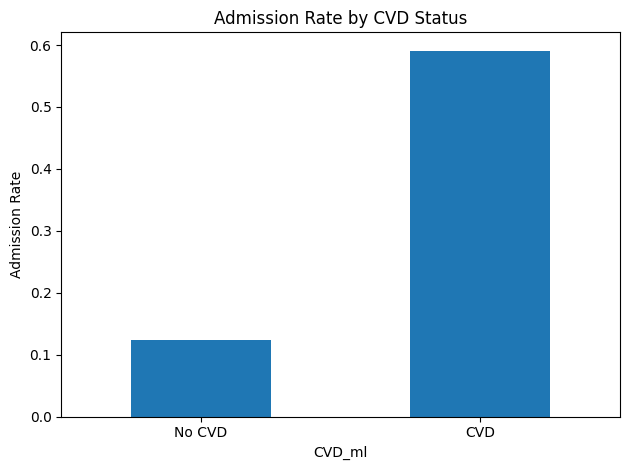

In [ ]:
plot_df = analysis_df.groupby("CVD_ml")["Admission"].mean()

plot_df.plot(kind="bar")
plt.xticks([0, 1], ["No CVD", "CVD"], rotation=0)
plt.ylabel("Admission Rate")
plt.title("Admission Rate by CVD Status")
plt.tight_layout()
plt.show()

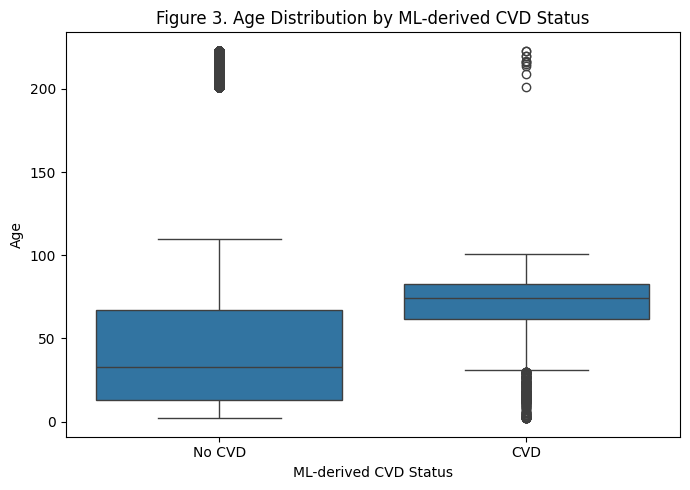

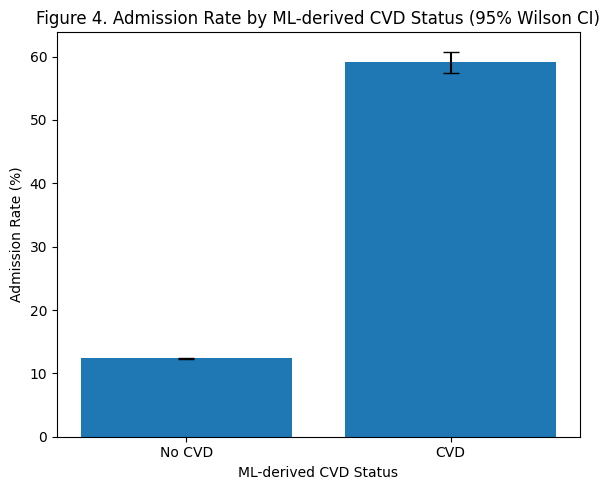

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from statsmodels.stats.proportion import proportion_confint


plt.figure(figsize=(7, 5))
sns.boxplot(data=analysis_df, x="CVD_ml", y="Age")
plt.xticks([0, 1], ["No CVD", "CVD"])
plt.xlabel("ML-derived CVD Status")
plt.ylabel("Age")
plt.title("Figure 3. Age Distribution by ML-derived CVD Status")
plt.tight_layout()
plt.savefig("figure3_age_boxplot_cvdml.png", dpi=300, bbox_inches="tight")
plt.show()



admission_summary = (
    analysis_df.groupby("CVD_ml")["Admission"]
    .agg(admitted="sum", n="count")
    .reset_index()
)

admission_summary["rate"] = admission_summary["admitted"] / admission_summary["n"]


ci_low, ci_high = proportion_confint(
    count=admission_summary["admitted"],
    nobs=admission_summary["n"],
    alpha=0.05,
    method="wilson"
)

admission_summary["ci_low"] = ci_low
admission_summary["ci_high"] = ci_high


admission_summary["rate_pct"] = admission_summary["rate"] * 100
admission_summary["ci_low_pct"] = admission_summary["ci_low"] * 100
admission_summary["ci_high_pct"] = admission_summary["ci_high"] * 100


yerr = [
    admission_summary["rate_pct"] - admission_summary["ci_low_pct"],
    admission_summary["ci_high_pct"] - admission_summary["rate_pct"]
]

plt.figure(figsize=(6, 5))
plt.bar(
    admission_summary["CVD_ml"],
    admission_summary["rate_pct"],
    yerr=yerr,
    capsize=6
)

plt.xticks([0, 1], ["No CVD", "CVD"])
plt.xlabel("ML-derived CVD Status")
plt.ylabel("Admission Rate (%)")
plt.title("Figure 4. Admission Rate by ML-derived CVD Status (95% Wilson CI)")
plt.tight_layout()
plt.savefig("figure4_admission_rate_cvdml.png", dpi=300, bbox_inches="tight")
plt.show()

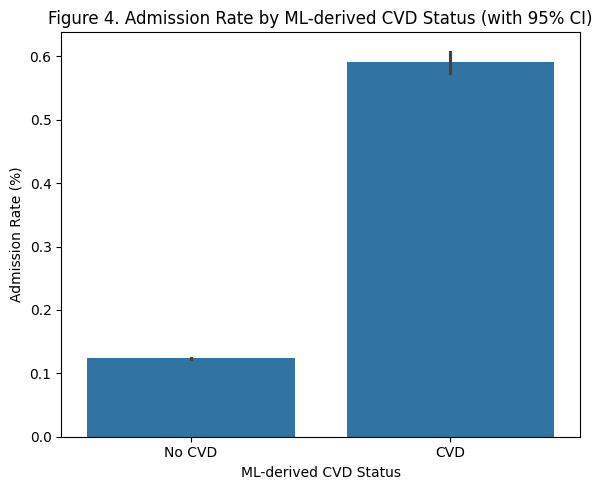

In [ ]:
plt.figure(figsize=(6, 5))
sns.barplot(data=analysis_df, x="CVD_ml", y="Admission", errorbar='ci')
plt.xticks([0, 1], ["No CVD", "CVD"])
plt.xlabel("ML-derived CVD Status")
plt.ylabel("Admission Rate (%)")
plt.title("Figure 4. Admission Rate by ML-derived CVD Status (with 95% CI)")
plt.tight_layout()
plt.savefig("figure4_admission_rate_cvdml.png", dpi=300, bbox_inches="tight")
plt.show()

TF-IDF + Linear SVM + Gradient Boosting

In [ ]:

svm_base = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_clf = CalibratedClassifierCV(
    estimator=svm_base,
    method="sigmoid",
    cv=5
)

svm_clf.fit(X_train_tfidf, y_train)

y_pred_svm = svm_clf.predict(X_test_tfidf)
y_prob_svm = svm_clf.predict_proba(X_test_tfidf)[:, 1]

print("TF-IDF + Linear SVM")
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print("AUROC:", roc_auc_score(y_test, y_prob_svm))

TF-IDF + Linear SVM
[[71756    27]
 [   24   528]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71783
           1       0.95      0.96      0.95       552

    accuracy                           1.00     72335
   macro avg       0.98      0.98      0.98     72335
weighted avg       1.00      1.00      1.00     72335

AUROC: 0.9989873616679256


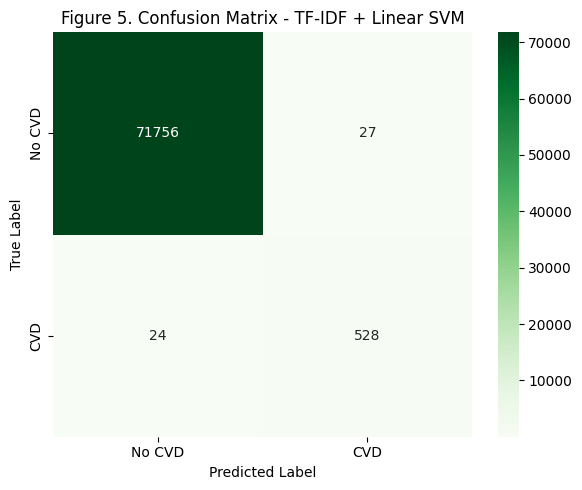

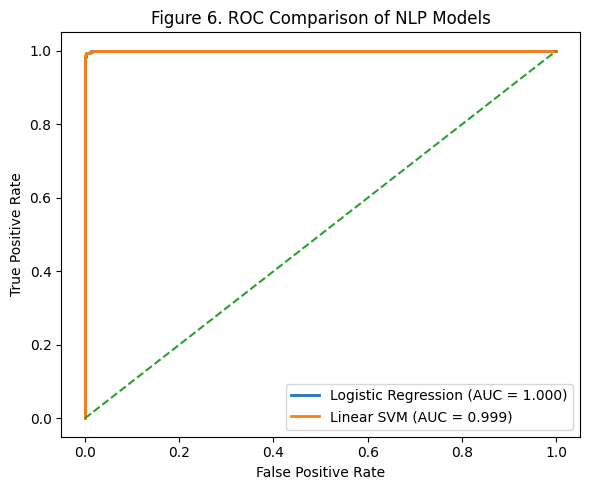

In [ ]:

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No CVD", "CVD"],
            yticklabels=["No CVD", "CVD"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Figure 5. Confusion Matrix - TF-IDF + Linear SVM")
plt.tight_layout()
plt.savefig("figure5_confusion_svm.png", dpi=300, bbox_inches="tight")
plt.show()


fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(6, 5))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})", linewidth=2)
plt.plot(fpr_svm, tpr_svm, label=f"Linear SVM (AUC = {auc_svm:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Figure 6. ROC Comparison of NLP Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figure6_roc_comparison_log_svm.png", dpi=300, bbox_inches="tight")
plt.show()

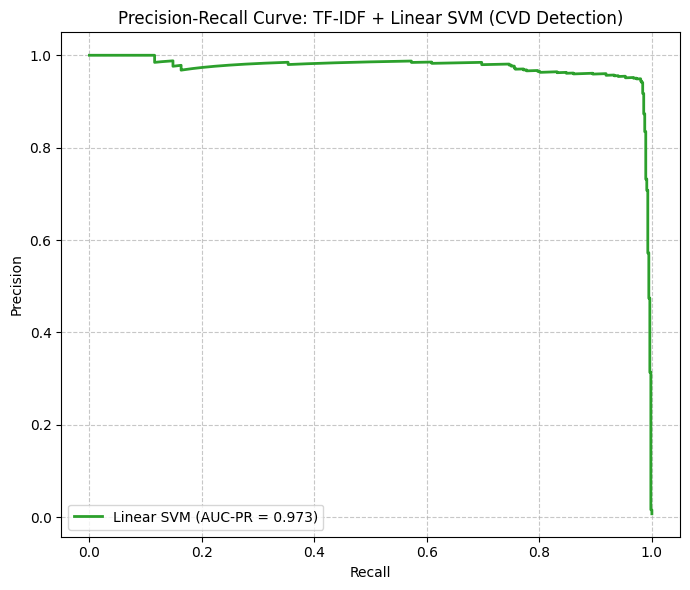

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt


precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_prob_svm)
auc_pr_svm = auc(recall_svm, precision_svm)

plt.figure(figsize=(7, 6))
plt.plot(recall_svm, precision_svm, label=f'Linear SVM (AUC-PR = {auc_pr_svm:.3f})', color='tab:green', linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: TF-IDF + Linear SVM (CVD Detection)')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('figure_pr_curve_svm.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
X_all_tfidf = tfidf.transform(df["combined_text"])

df["CVD_svm_prob"] = svm_clf.predict_proba(X_all_tfidf)[:, 1]
df["CVD_svm"] = (df["CVD_svm_prob"] >= 0.5).astype(int)

print(df["CVD_svm"].value_counts())
print(df[["CVD_svm_prob", "CVD_svm"]].head())

CVD_svm
0    358852
1      2820
Name: count, dtype: int64
   CVD_svm_prob  CVD_svm
0      0.000066        0
1      0.000534        0
2      0.000316        0
3      0.000104        0
4      0.000034        0


In [ ]:
analysis_df = df[df["Admission"].notna()].copy()
analysis_df = analysis_df[analysis_df["Age"] > 0].copy()

analysis_df["Sex"] = analysis_df["Sex"].replace({3: np.nan})
analysis_df = analysis_df[analysis_df["Sex"].isin([1, 2])].copy()
analysis_df["Sex_binary"] = analysis_df["Sex"].apply(lambda x: 1 if x == 1 else 0)

print(analysis_df.shape)
print(analysis_df["Admission"].value_counts(dropna=False))
print(analysis_df["Sex_binary"].value_counts(dropna=False))

(353342, 38)
Admission
0.0    308124
1.0     45218
Name: count, dtype: int64
Sex_binary
1    193258
0    160084
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score


gb_features = [
    "CVD_ml",
    "Age",
    "Sex_binary",
    "Alcohol",
    "Drug",
    "Fire_Involvement",
    "Body_Part",
    "Diagnosis",
    "Location"
]

gb_df = analysis_df[gb_features + ["Admission"]].copy()


gb_df = gb_df.dropna(subset=["Admission", "CVD_ml", "Age", "Sex_binary"])


for col in ["Alcohol", "Drug", "Fire_Involvement"]:
    if col in gb_df.columns:
        gb_df[col] = gb_df[col].fillna(0)


for col in ["Body_Part", "Diagnosis", "Location"]:
    gb_df[col] = gb_df[col].fillna("Missing")

X_gb = gb_df[gb_features].copy()
y_gb = gb_df["Admission"].astype(int)


X_gb = pd.get_dummies(
    X_gb,
    columns=["Body_Part", "Diagnosis", "Location"],
    drop_first=True
)

X_train_gb, X_test_gb, y_train_gb, y_test_gb = train_test_split(
    X_gb,
    y_gb,
    test_size=0.2,
    random_state=42,
    stratify=y_gb
)

gb_clf = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_clf.fit(X_train_gb, y_train_gb)

y_pred_gb = gb_clf.predict(X_test_gb)
y_prob_gb = gb_clf.predict_proba(X_test_gb)[:, 1]

print("Gradient Boosting Admission Model (Fair Expanded Features)")
print(confusion_matrix(y_test_gb, y_pred_gb))
print(classification_report(y_test_gb, y_pred_gb))
print("AUROC:", roc_auc_score(y_test_gb, y_prob_gb))

Gradient Boosting Admission Model (Fair Expanded Features)
[[60766   859]
 [ 6684  2360]]
              precision    recall  f1-score   support

           0       0.90      0.99      0.94     61625
           1       0.73      0.26      0.38      9044

    accuracy                           0.89     70669
   macro avg       0.82      0.62      0.66     70669
weighted avg       0.88      0.89      0.87     70669

AUROC: 0.8559886038326935


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

precision, recall, thresholds = precision_recall_curve(y_test_gb, y_prob_gb)

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-12)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold by F1:", best_threshold)
print("Best F1:", f1_scores[best_idx])


y_pred_default = (y_prob_gb >= 0.5).astype(int)

print("\nDefault threshold = 0.5")
print("Accuracy:", accuracy_score(y_test_gb, y_pred_default))
print("Precision:", precision_score(y_test_gb, y_pred_default, zero_division=0))
print("Recall:", recall_score(y_test_gb, y_pred_default, zero_division=0))
print("F1:", f1_score(y_test_gb, y_pred_default, zero_division=0))
print(confusion_matrix(y_test_gb, y_pred_default))


y_pred_tuned = (y_prob_gb >= best_threshold).astype(int)

print("\nTuned threshold =", best_threshold)
print("Accuracy:", accuracy_score(y_test_gb, y_pred_tuned))
print("Precision:", precision_score(y_test_gb, y_pred_tuned, zero_division=0))
print("Recall:", recall_score(y_test_gb, y_pred_tuned, zero_division=0))
print("F1:", f1_score(y_test_gb, y_pred_tuned, zero_division=0))
print(confusion_matrix(y_test_gb, y_pred_tuned))

threshold_table = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision[:-1],
    "Recall": recall[:-1],
    "F1": f1_scores
}).sort_values("F1", ascending=False)

print(threshold_table.head(10))
threshold_table.to_excel("gb_threshold_tuning_results.xlsx", index=False)

Best threshold by F1: 0.22948296768440268
Best F1: 0.5095553453164451

Default threshold = 0.5
Accuracy: 0.8932629582985467
Precision: 0.7331469400434918
Recall: 0.26094648385670055
F1: 0.3848976596265188
[[60766   859]
 [ 6684  2360]]

Tuned threshold = 0.22948296768440268
Accuracy: 0.8532878631365945
Precision: 0.445271164021164
Recall: 0.5955329500221141
F1: 0.5095553453169347
[[54915  6710]
 [ 3658  5386]]
      Threshold  Precision    Recall        F1
7764   0.229483   0.445271  0.595533  0.509555
7763   0.229436   0.445234  0.595533  0.509531
7766   0.229780   0.445262  0.595422  0.509509
7765   0.229696   0.445225  0.595422  0.509485
7759   0.229209   0.444692  0.596086  0.509378
7751   0.228490   0.443706  0.597855  0.509374
7768   0.229855   0.445364  0.594870  0.509373
7760   0.229310   0.444719  0.595975  0.509356
7750   0.228340   0.443633  0.597855  0.509326
7762   0.229413   0.444710  0.595865  0.509309


In [57]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


def bootstrap_metrics_ci(y_true, y_pred, y_prob, n_bootstrap=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(y_true)

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)

    accs, precs, recs, f1s, aucs = [], [], [], [], []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)

        y_true_b = y_true[idx]
        y_pred_b = y_pred[idx]
        y_prob_b = y_prob[idx]

        accs.append(accuracy_score(y_true_b, y_pred_b))
        precs.append(precision_score(y_true_b, y_pred_b, zero_division=0))
        recs.append(recall_score(y_true_b, y_pred_b, zero_division=0))
        f1s.append(f1_score(y_true_b, y_pred_b, zero_division=0))

        if len(np.unique(y_true_b)) == 2:
            aucs.append(roc_auc_score(y_true_b, y_prob_b))
        else:
            aucs.append(np.nan)

    def get_ci(values):
        values = np.array(values, dtype=float)
        point = np.nanmean(values)
        low = np.nanpercentile(values, 2.5)
        high = np.nanpercentile(values, 97.5)
        return point, low, high

    return {
        "Accuracy": get_ci(accs),
        "Precision": get_ci(precs),
        "Recall": get_ci(recs),
        "F1": get_ci(f1s),
        "AUROC": get_ci(aucs)
    }

def format_ci(ci_tuple):
    point, low, high = ci_tuple
    return f"{point:.3f} ({low:.3f}–{high:.3f})"



y_pred_gb_tuned = (y_prob_gb >= best_threshold).astype(int)

print(f"Gradient Boosting Model Metrics (Tuned Threshold: {best_threshold:.3f}) ")


gb_metrics_ci = bootstrap_metrics_ci(
    y_true=y_test_gb,
    y_pred=y_pred_gb_tuned,
    y_prob=y_prob_gb,
    n_bootstrap=2000,
    random_state=42
)

print(f"Accuracy:  {format_ci(gb_metrics_ci['Accuracy'])}")
print(f"Precision: {format_ci(gb_metrics_ci['Precision'])}")
print(f"Recall:    {format_ci(gb_metrics_ci['Recall'])}")
print(f"F1-Score:  {format_ci(gb_metrics_ci['F1'])}")
print(f"AUROC:     {format_ci(gb_metrics_ci['AUROC'])}")

--- Gradient Boosting Model Metrics (Tuned Threshold: 0.229) ---
Accuracy:  0.853 (0.851–0.856)
Precision: 0.445 (0.437–0.453)
Recall:    0.595 (0.586–0.605)
F1-Score:  0.509 (0.501–0.517)
AUROC:     0.856 (0.852–0.860)


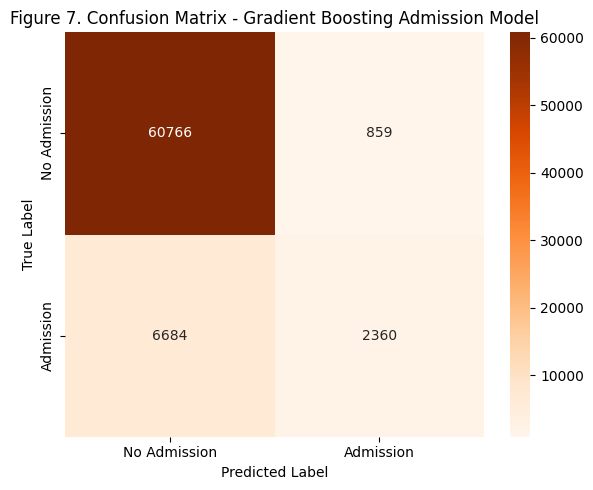

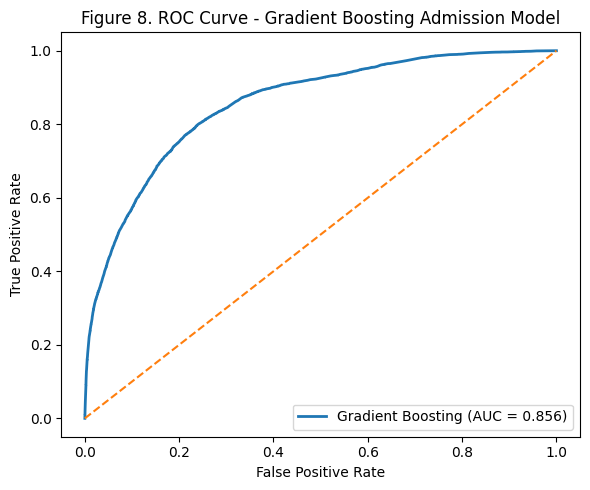

In [ ]:

cm_gb = confusion_matrix(y_test_gb, y_pred_gb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["No Admission", "Admission"],
            yticklabels=["No Admission", "Admission"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Figure 7. Confusion Matrix - Gradient Boosting Admission Model")
plt.tight_layout()
plt.savefig("figure7_confusion_gb.png", dpi=300, bbox_inches="tight")
plt.show()


fpr_gb, tpr_gb, _ = roc_curve(y_test_gb, y_prob_gb)
auc_gb = auc(fpr_gb, tpr_gb)

plt.figure(figsize=(6, 5))
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {auc_gb:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Figure 8. ROC Curve - Gradient Boosting Admission Model")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figure8_roc_gb.png", dpi=300, bbox_inches="tight")
plt.show()

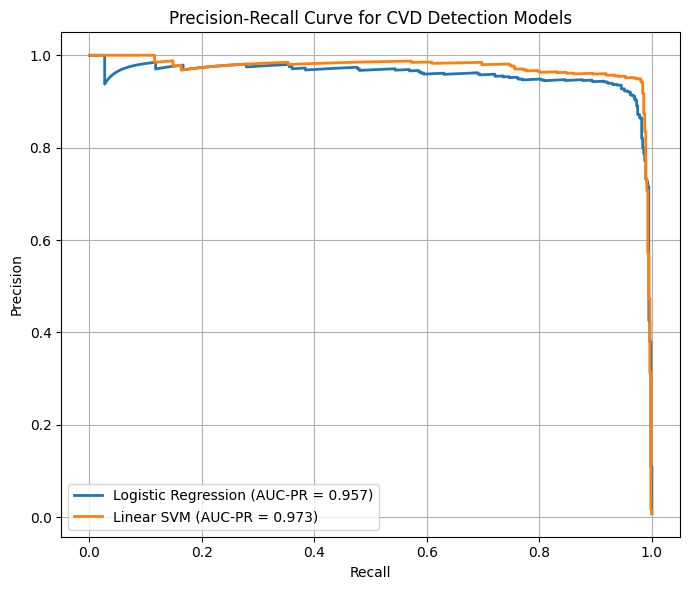

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt


precision_log, recall_log, _ = precision_recall_curve(y_test, y_prob)
auc_pr_log = auc(recall_log, precision_log)


precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_prob_svm)
auc_pr_svm = auc(recall_svm, precision_svm)

plt.figure(figsize=(7, 6))
plt.plot(recall_log, precision_log, label=f'Logistic Regression (AUC-PR = {auc_pr_log:.3f})', linewidth=2)
plt.plot(recall_svm, precision_svm, label=f'Linear SVM (AUC-PR = {auc_pr_svm:.3f})', linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for CVD Detection Models')
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.savefig('figure_pr_curve_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

     Merged_Feature  Importance
0               Age    0.436937
4         Diagnosis    0.271301
2         Body_Part    0.211315
3            CVD_ml    0.033182
5              Drug    0.016197
6  Fire_Involvement    0.011455
7          Location    0.011118
1           Alcohol    0.005089
8        Sex_binary    0.003407


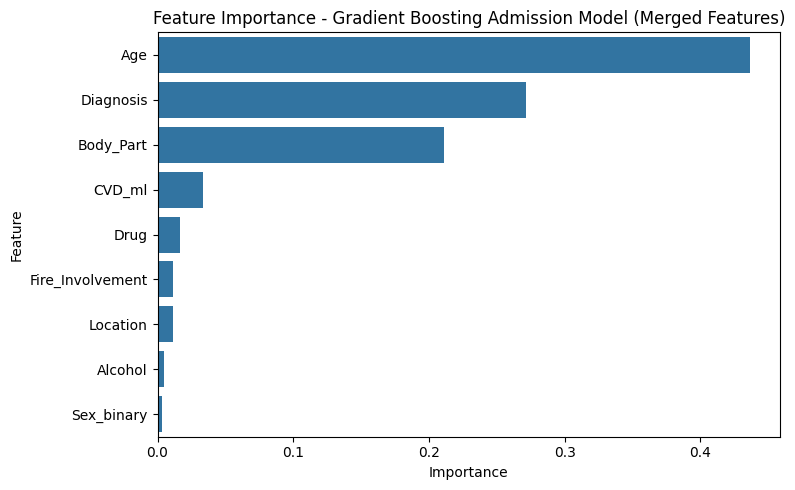

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


feature_importance = pd.DataFrame({
    "Feature": X_train_gb.columns,
    "Importance": gb_clf.feature_importances_
})


def merge_feature_name(col):
    if col.startswith("Diagnosis_"):
        return "Diagnosis"
    elif col.startswith("Location_"):
        return "Location"
    elif col.startswith("Body_Part_"):
        return "Body_Part"
    else:
        return col

feature_importance["Merged_Feature"] = feature_importance["Feature"].apply(merge_feature_name)


merged_importance = (
    feature_importance
    .groupby("Merged_Feature", as_index=False)["Importance"]
    .sum()
    .sort_values(by="Importance", ascending=False)
)

print(merged_importance)
merged_importance.to_excel("table_feature_importance_merged.xlsx", index=False)


plt.figure(figsize=(8, 5))
sns.barplot(data=merged_importance, x="Importance", y="Merged_Feature")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Gradient Boosting Admission Model (Merged Features)")
plt.tight_layout()
plt.savefig("figure_feature_importance_merged.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
df.to_excel("step_method3_svm_outputs.xlsx", index=False)
gb_df.to_excel("step_method3_gb_dataset.xlsx", index=False)

In [ ]:
comparison_rows = []


rule_y_true = df_model["CVD"]
rule_y_pred = df_model["CVD"]

comparison_rows.append({
    "Method": "Rule-based",
    "Accuracy": accuracy_score(rule_y_true, rule_y_pred),
    "Precision": precision_score(rule_y_true, rule_y_pred, zero_division=0),
    "Recall": recall_score(rule_y_true, rule_y_pred, zero_division=0),
    "F1": f1_score(rule_y_true, rule_y_pred, zero_division=0)
})


y_pred_log = clf.predict(X_test_tfidf)
y_prob_log = clf.predict_proba(X_test_tfidf)[:, 1]

comparison_rows.append({
    "Method": "TF-IDF + Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_log),
    "Precision": precision_score(y_test, y_pred_log, zero_division=0),
    "Recall": recall_score(y_test, y_pred_log, zero_division=0),
    "F1": f1_score(y_test, y_pred_log, zero_division=0),
    "AUROC": roc_auc_score(y_test, y_prob_log)
})


comparison_rows.append({
    "Method": "TF-IDF + Linear SVM",
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(y_test, y_pred_svm, zero_division=0),
    "Recall": recall_score(y_test, y_pred_svm, zero_division=0),
    "F1": f1_score(y_test, y_pred_svm, zero_division=0),
    "AUROC": roc_auc_score(y_test, y_prob_svm)
})

comparison_table = pd.DataFrame(comparison_rows)
print(comparison_table)
comparison_table.to_excel("table_cvd_method_comparison.xlsx", index=False)

                         Method  Accuracy  Precision    Recall        F1  \
0                    Rule-based  1.000000   1.000000  1.000000  1.000000   
1  TF-IDF + Logistic Regression  0.998562   0.852201  0.981884  0.912458   
2           TF-IDF + Linear SVM  0.999295   0.951351  0.956522  0.953930   

      AUROC  
0       NaN  
1  0.999640  
2  0.998987  


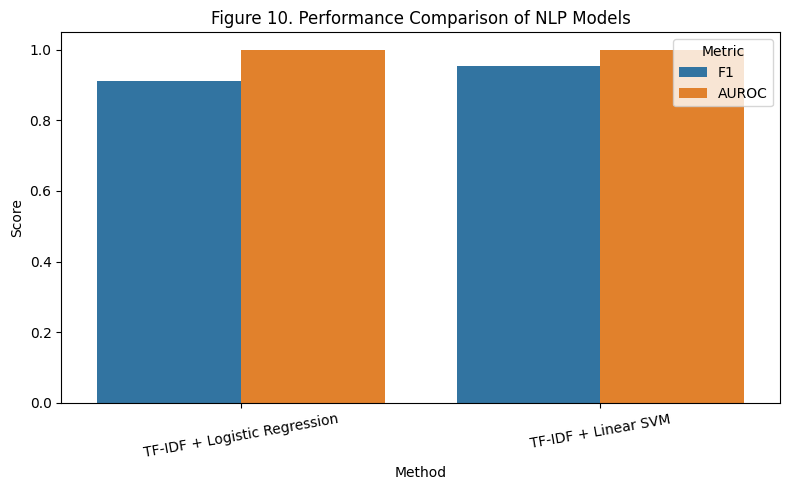

In [ ]:
plot_metrics = comparison_table.copy()

metrics_to_plot = ["F1", "AUROC"]
plot_metrics = plot_metrics[plot_metrics["Method"] != "Rule-based"].copy()

plot_metrics_melted = plot_metrics.melt(
    id_vars="Method",
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_metrics_melted, x="Method", y="Score", hue="Metric")
plt.xlabel("Method")
plt.ylabel("Score")
plt.title("Figure 10. Performance Comparison of NLP Models")
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig("figure10_method_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
admission_rows = []



from sklearn.linear_model import LogisticRegression

adm_features_log = ["CVD_ml", "Age", "Sex_binary"]
adm_df_log = analysis_df[adm_features_log + ["Admission"]].dropna().copy()

X_adm_log = adm_df_log[adm_features_log]
y_adm_log = adm_df_log["Admission"]

X_train_adm_log, X_test_adm_log, y_train_adm_log, y_test_adm_log = train_test_split(
    X_adm_log,
    y_adm_log,
    test_size=0.2,
    random_state=42,
    stratify=y_adm_log
)

adm_log_clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
adm_log_clf.fit(X_train_adm_log, y_train_adm_log)

y_pred_adm_log = adm_log_clf.predict(X_test_adm_log)
y_prob_adm_log = adm_log_clf.predict_proba(X_test_adm_log)[:, 1]

admission_rows.append({
    "Method": "Admission: Logistic (CVD_ml + Age + Sex)",
    "Accuracy": accuracy_score(y_test_adm_log, y_pred_adm_log),
    "Precision": precision_score(y_test_adm_log, y_pred_adm_log, zero_division=0),
    "Recall": recall_score(y_test_adm_log, y_pred_adm_log, zero_division=0),
    "F1": f1_score(y_test_adm_log, y_pred_adm_log, zero_division=0),
    "AUROC": roc_auc_score(y_test_adm_log, y_prob_adm_log)
})

admission_rows.append({
    "Method": "Admission: Gradient Boosting (CVD_svm_prob + CVD_svm + Age + Sex)",
    "Accuracy": accuracy_score(y_test_gb, y_pred_gb),
    "Precision": precision_score(y_test_gb, y_pred_gb, zero_division=0),
    "Recall": recall_score(y_test_gb, y_pred_gb, zero_division=0),
    "F1": f1_score(y_test_gb, y_pred_gb, zero_division=0),
    "AUROC": roc_auc_score(y_test_gb, y_prob_gb)
})

admission_comparison_table = pd.DataFrame(admission_rows)
print(admission_comparison_table)
admission_comparison_table.to_excel("table_admission_method_comparison.xlsx", index=False)

                                              Method  Accuracy  Precision  \
0           Admission: Logistic (CVD_ml + Age + Sex)  0.708642   0.257274   
1  Admission: Gradient Boosting (CVD_svm_prob + C...  0.893263   0.733147   

     Recall        F1     AUROC  
0  0.676581  0.372792  0.722675  
1  0.260946  0.384898  0.855989  


In [ ]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split




def bootstrap_metrics_ci(y_true, y_pred, y_prob, n_bootstrap=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(y_true)

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)

    accs, precs, recs, f1s, aucs = [], [], [], [], []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)

        y_true_b = y_true[idx]
        y_pred_b = y_pred[idx]
        y_prob_b = y_prob[idx]

        accs.append(accuracy_score(y_true_b, y_pred_b))
        precs.append(precision_score(y_true_b, y_pred_b, zero_division=0))
        recs.append(recall_score(y_true_b, y_pred_b, zero_division=0))
        f1s.append(f1_score(y_true_b, y_pred_b, zero_division=0))

        if len(np.unique(y_true_b)) == 2:
            aucs.append(roc_auc_score(y_true_b, y_prob_b))
        else:
            aucs.append(np.nan)

    def get_ci(values):
        values = np.array(values, dtype=float)
        point = np.nanmean(values)
        low = np.nanpercentile(values, 2.5)
        high = np.nanpercentile(values, 97.5)
        return point, low, high

    return {
        "Accuracy": get_ci(accs),
        "Precision": get_ci(precs),
        "Recall": get_ci(recs),
        "F1": get_ci(f1s),
        "AUROC": get_ci(aucs)
    }


def format_ci(ci_tuple):
    point, low, high = ci_tuple
    return f"{point:.3f} ({low:.3f}–{high:.3f})"


admission_rows = []

adm_features_log = ["CVD_ml", "Age", "Sex_binary"]
adm_df_log = analysis_df[adm_features_log + ["Admission"]].dropna().copy()

X_adm_log = adm_df_log[adm_features_log]
y_adm_log = adm_df_log["Admission"]

X_train_adm_log, X_test_adm_log, y_train_adm_log, y_test_adm_log = train_test_split(
    X_adm_log,
    y_adm_log,
    test_size=0.2,
    random_state=42,
    stratify=y_adm_log
)

adm_log_clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
adm_log_clf.fit(X_train_adm_log, y_train_adm_log)

y_pred_adm_log = adm_log_clf.predict(X_test_adm_log)
y_prob_adm_log = adm_log_clf.predict_proba(X_test_adm_log)[:, 1]

log_ci = bootstrap_metrics_ci(
    y_true=y_test_adm_log,
    y_pred=y_pred_adm_log,
    y_prob=y_prob_adm_log,
    n_bootstrap=2000,
    random_state=42
)

admission_rows.append({
    "Model": "Logistic (CVD_ml + Age + Sex)",
    "Accuracy": format_ci(log_ci["Accuracy"]),
    "Precision": format_ci(log_ci["Precision"]),
    "Recall": format_ci(log_ci["Recall"]),
    "F1": format_ci(log_ci["F1"]),
    "AUROC": format_ci(log_ci["AUROC"])
})



gb_ci = bootstrap_metrics_ci(
    y_true=y_test_gb,
    y_pred=y_pred_gb,
    y_prob=y_prob_gb,
    n_bootstrap=2000,
    random_state=42
)

admission_rows.append({
    "Model": "Gradient Boosting",
    "Accuracy": format_ci(gb_ci["Accuracy"]),
    "Precision": format_ci(gb_ci["Precision"]),
    "Recall": format_ci(gb_ci["Recall"]),
    "F1": format_ci(gb_ci["F1"]),
    "AUROC": format_ci(gb_ci["AUROC"])
})

admission_comparison_table = pd.DataFrame(admission_rows)
print(admission_comparison_table)
admission_comparison_table.to_excel("table_admission_method_comparison.xlsx", index=False)

                           Model             Accuracy            Precision  \
0  Logistic (CVD_ml + Age + Sex)  0.709 (0.705–0.712)  0.257 (0.252–0.263)   
1              Gradient Boosting  0.893 (0.891–0.895)  0.733 (0.718–0.748)   

                Recall                   F1                AUROC  
0  0.677 (0.667–0.686)  0.373 (0.366–0.380)  0.723 (0.717–0.728)  
1  0.261 (0.252–0.270)  0.385 (0.373–0.396)  0.856 (0.852–0.860)  


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


def bootstrap_metrics_ci(y_true, y_pred, y_prob, n_bootstrap=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)
    n = len(y_true)

    accs, precs, recs, f1s, aucs = [], [], [], [], []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)

        y_true_b = y_true[idx]
        y_pred_b = y_pred[idx]
        y_prob_b = y_prob[idx]

        accs.append(accuracy_score(y_true_b, y_pred_b))
        precs.append(precision_score(y_true_b, y_pred_b, zero_division=0))
        recs.append(recall_score(y_true_b, y_pred_b, zero_division=0))
        f1s.append(f1_score(y_true_b, y_pred_b, zero_division=0))

        if len(np.unique(y_true_b)) == 2:
            aucs.append(roc_auc_score(y_true_b, y_prob_b))
        else:
            aucs.append(np.nan)

    def summarize(values):
        values = np.asarray(values, dtype=float)
        return (
            np.nanmean(values),
            np.nanpercentile(values, 2.5),
            np.nanpercentile(values, 97.5)
        )

    return {
        "Accuracy": summarize(accs),
        "Precision": summarize(precs),
        "Recall": summarize(recs),
        "F1": summarize(f1s),
        "AUROC": summarize(aucs)
    }


def add_result_row(rows_numeric, rows_formatted, experiment_name, model_name, metrics_dict):
    numeric_row = {
        "Experiment": experiment_name,
        "Model": model_name
    }
    formatted_row = {
        "Experiment": experiment_name,
        "Model": model_name
    }

    for metric in ["Accuracy", "Precision", "Recall", "F1", "AUROC"]:
        point, low, high = metrics_dict[metric]

        numeric_row[f"{metric}"] = point
        numeric_row[f"{metric}_CI_Low"] = low
        numeric_row[f"{metric}_CI_High"] = high

        formatted_row[metric] = f"{point:.3f} ({low:.3f}–{high:.3f})"

    rows_numeric.append(numeric_row)
    rows_formatted.append(formatted_row)


def train_and_evaluate_models(X, y, experiment_name, rows_numeric, rows_formatted):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    log_clf = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )
    log_clf.fit(X_train, y_train)

    y_pred_log = log_clf.predict(X_test)
    y_prob_log = log_clf.predict_proba(X_test)[:, 1]

    log_metrics = bootstrap_metrics_ci(
        y_true=y_test,
        y_pred=y_pred_log,
        y_prob=y_prob_log,
        n_bootstrap=2000,
        random_state=42
    )

    add_result_row(
        rows_numeric,
        rows_formatted,
        experiment_name,
        "Logistic Regression",
        log_metrics
    )

    gb_clf = GradientBoostingClassifier(random_state=42)
    gb_clf.fit(X_train, y_train)

    y_pred_gb = gb_clf.predict(X_test)
    y_prob_gb = gb_clf.predict_proba(X_test)[:, 1]

    gb_metrics = bootstrap_metrics_ci(
        y_true=y_test,
        y_pred=y_pred_gb,
        y_prob=y_prob_gb,
        n_bootstrap=2000,
        random_state=42
    )

    add_result_row(
        rows_numeric,
        rows_formatted,
        experiment_name,
        "Gradient Boosting",
        gb_metrics
    )


admission_rows_numeric = []
admission_rows_formatted = []



minimal_features = ["CVD_ml", "Age", "Sex_binary", "Admission"]

adm_df_min = analysis_df[minimal_features].dropna().copy()

X_min = adm_df_min[["CVD_ml", "Age", "Sex_binary"]]
y_min = adm_df_min["Admission"].astype(int)

train_and_evaluate_models(
    X=X_min,
    y=y_min,
    experiment_name="Minimal fair features: CVD_ml + Age + Sex_binary",
    rows_numeric=admission_rows_numeric,
    rows_formatted=admission_rows_formatted
)




numeric_features = ["CVD_ml", "Age", "Sex_binary", "Alcohol", "Drug", "Fire_Involvement"]
categorical_features = ["Body_Part", "Diagnosis", "Location"]

expanded_cols = numeric_features + categorical_features + ["Admission"]
adm_df_exp = analysis_df[expanded_cols].copy()

adm_df_exp = adm_df_exp.dropna(subset=["Admission", "CVD_ml", "Age", "Sex_binary"])

for col in ["Alcohol", "Drug", "Fire_Involvement"]:
    if col in adm_df_exp.columns:
        adm_df_exp[col] = adm_df_exp[col].fillna(0)

for col in categorical_features:
    adm_df_exp[col] = adm_df_exp[col].fillna("Missing")

X_exp = adm_df_exp[numeric_features + categorical_features].copy()
y_exp = adm_df_exp["Admission"].astype(int)

X_exp_encoded = pd.get_dummies(
    X_exp,
    columns=categorical_features,
    drop_first=True
)

train_and_evaluate_models(
    X=X_exp_encoded,
    y=y_exp,
    experiment_name="Expanded fair features: CVD_ml + Age + Sex_binary + Alcohol + Drug + Fire_Involvement + Body_Part + Diagnosis + Location",
    rows_numeric=admission_rows_numeric,
    rows_formatted=admission_rows_formatted
)


admission_comparison_table_numeric = pd.DataFrame(admission_rows_numeric)
admission_comparison_table_formatted = pd.DataFrame(admission_rows_formatted)

print("\nNUMERIC TABLE WITH BOOTSTRAP CIs")
print(admission_comparison_table_numeric)

print("\nPAPER-READY FORMATTED TABLE")
print(admission_comparison_table_formatted)

admission_comparison_table_numeric.to_excel(
    "table_admission_model_comparison_bootstrap_numeric.xlsx",
    index=False
)

admission_comparison_table_formatted.to_excel(
    "table_admission_model_comparison_bootstrap_formatted.xlsx",
    index=False
)


NUMERIC TABLE WITH BOOTSTRAP CIs
                                          Experiment                Model  \
0   Minimal fair features: CVD_ml + Age + Sex_binary  Logistic Regression   
1   Minimal fair features: CVD_ml + Age + Sex_binary    Gradient Boosting   
2  Expanded fair features: CVD_ml + Age + Sex_bin...  Logistic Regression   
3  Expanded fair features: CVD_ml + Age + Sex_bin...    Gradient Boosting   

   Accuracy  Accuracy_CI_Low  Accuracy_CI_High  Precision  Precision_CI_Low  \
0  0.708661         0.705387          0.711925   0.257333          0.251993   
1  0.874334         0.871796          0.876721   0.647663          0.606818   
2  0.709622         0.706434          0.712915   0.273335          0.267931   
3  0.893335         0.891027          0.895570   0.729788          0.715112   

   Precision_CI_High    Recall  Recall_CI_Low  Recall_CI_High        F1  \
0           0.262857  0.676653       0.667071        0.685794  0.372858   
1           0.686651  0.039901    

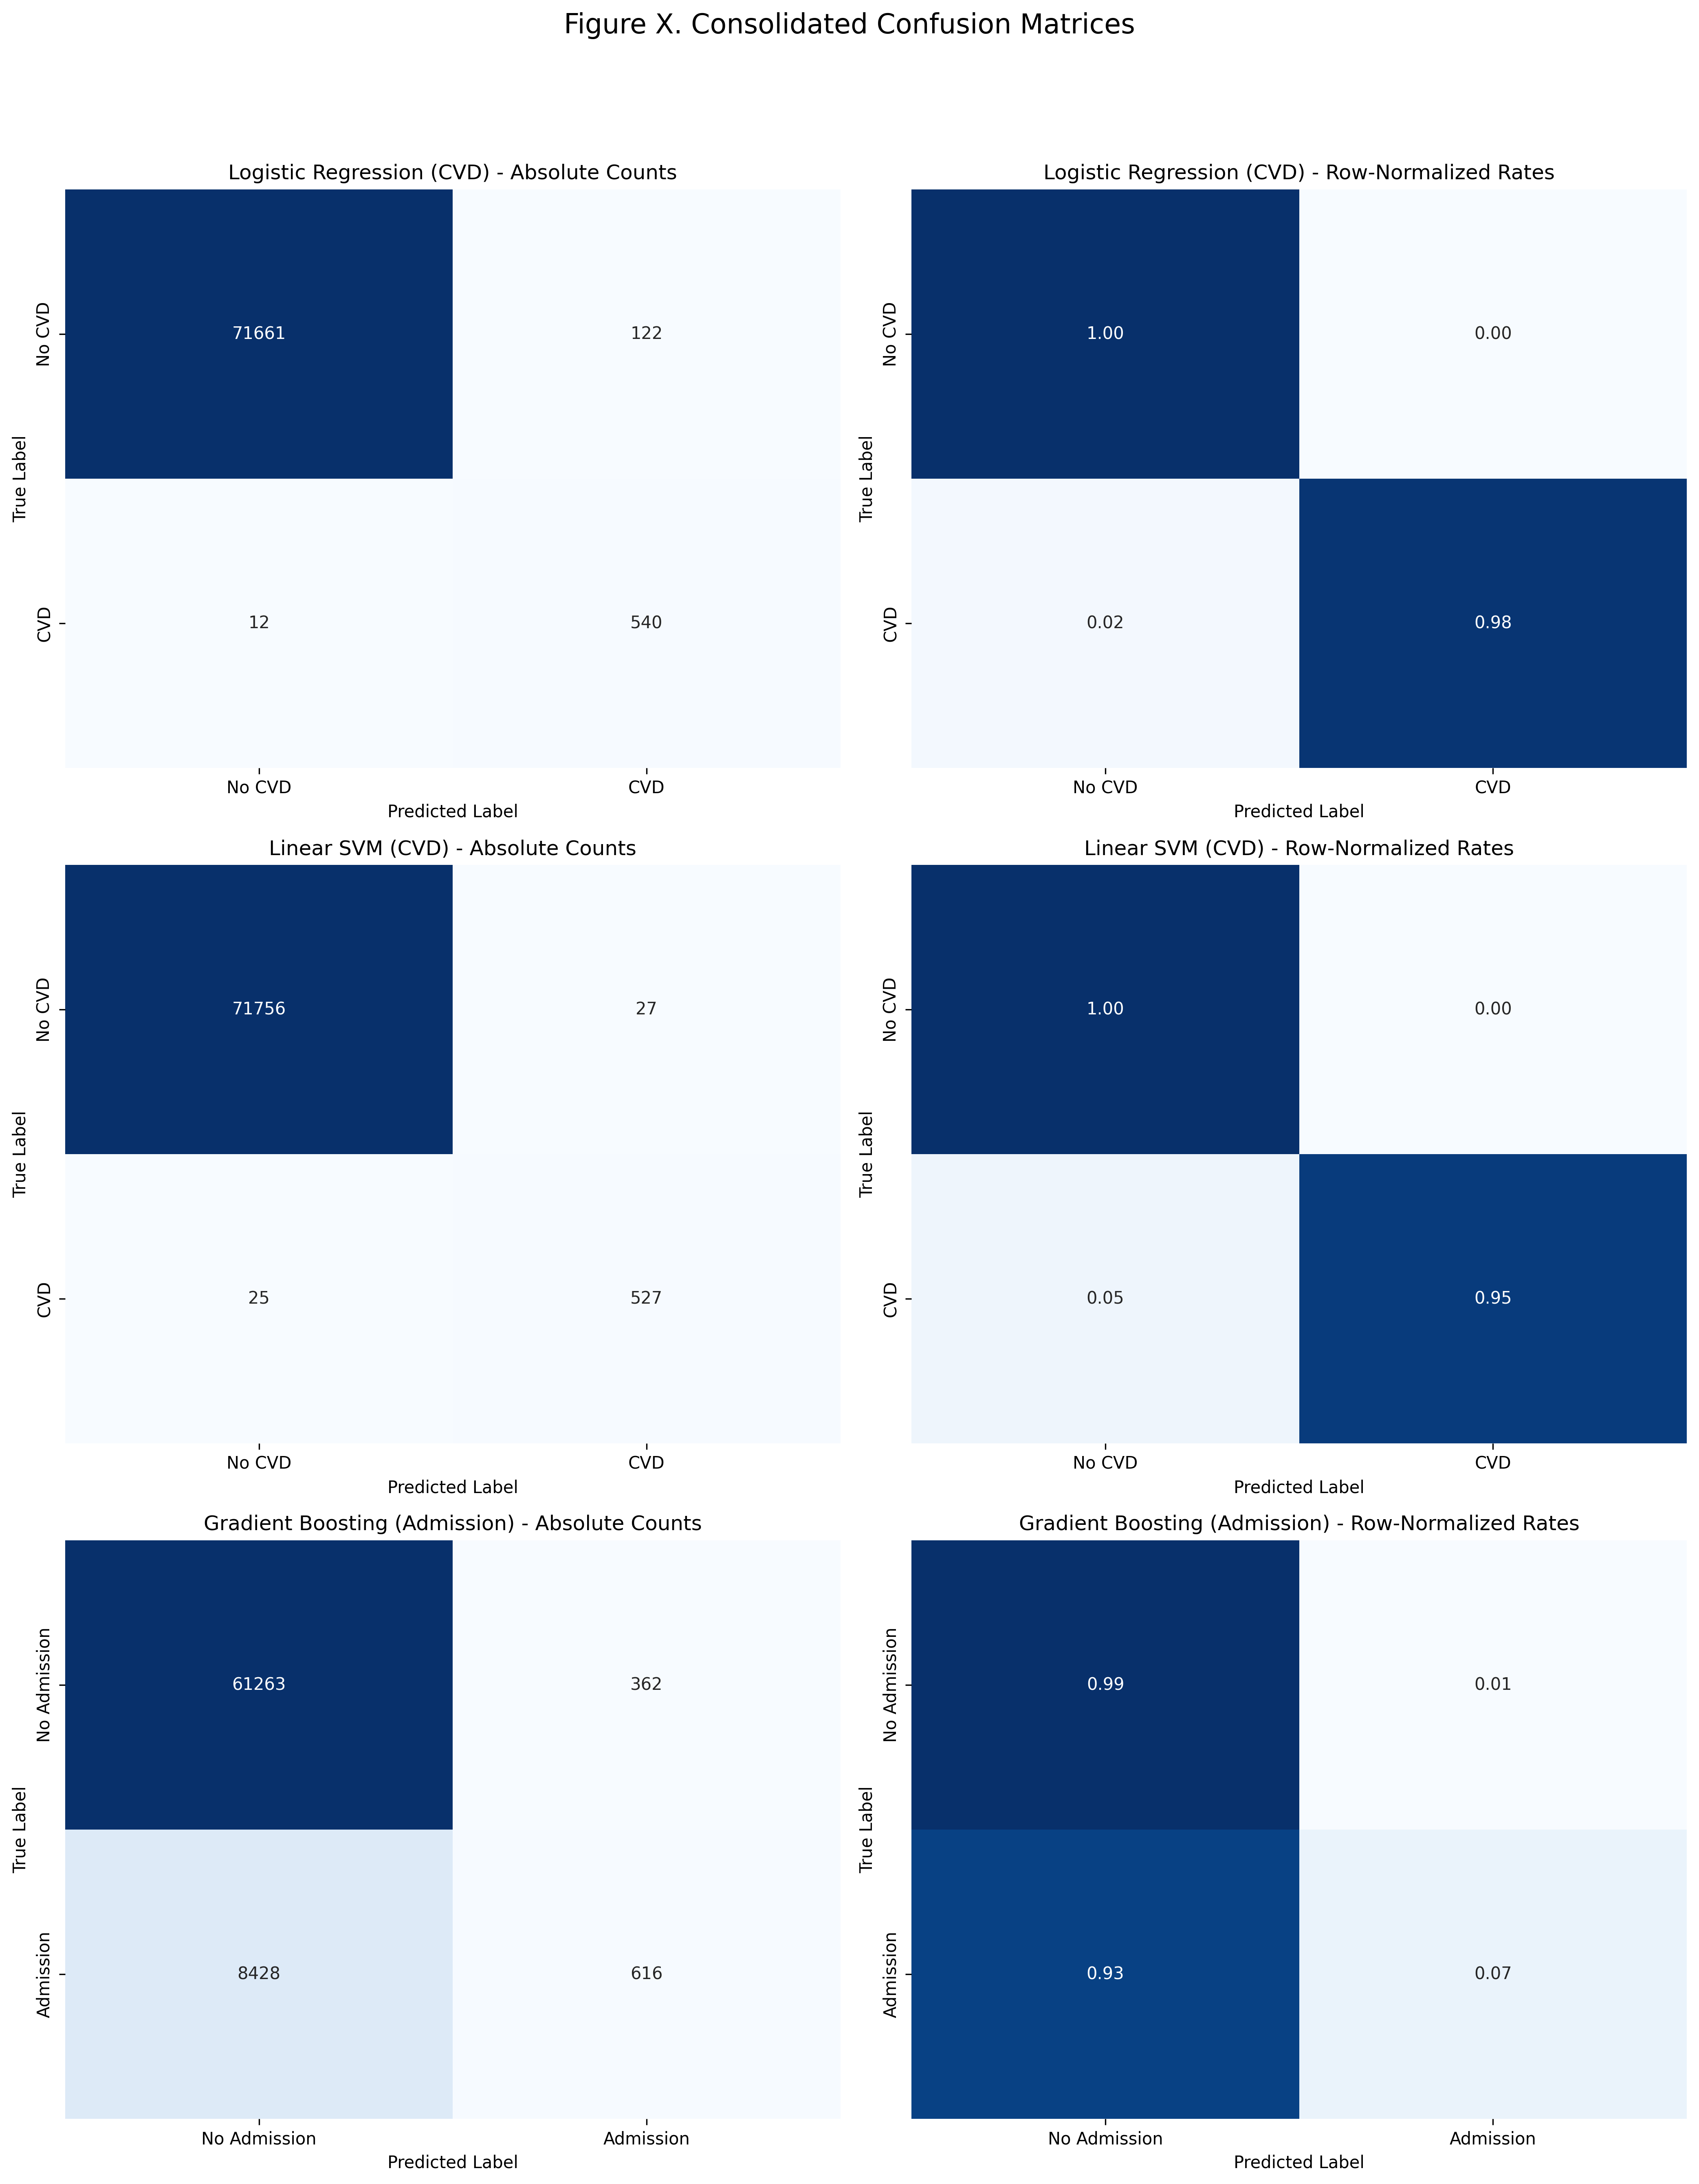

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

cm_log = np.array([[71661, 122], [12, 540]])
cm_svm = np.array([[71756, 27], [25, 527]])
cm_gb = np.array([[61263, 362], [8428, 616]])


models = {
    "Logistic Regression (CVD)": {
        "cm": cm_log,
        "labels": ["No CVD", "CVD"]
    },
    "Linear SVM (CVD)": {
        "cm": cm_svm,
        "labels": ["No CVD", "CVD"]
    },
    "Gradient Boosting (Admission)": {
        "cm": cm_gb,
        "labels": ["No Admission", "Admission"]
    }
}

fig, axes = plt.subplots(3, 2, figsize=(14, 18), dpi=300)
fig.suptitle("Figure X. Consolidated Confusion Matrices", fontsize=16, y=1.02)

for i, (model_name, data) in enumerate(models.items()):
    cm = data["cm"]
    class_labels = data["labels"]


    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i, 0],
        xticklabels=class_labels,
        yticklabels=class_labels,
        cbar=False
    )
    axes[i, 0].set_title(f"{model_name} - Absolute Counts", fontsize=12)
    axes[i, 0].set_xlabel("Predicted Label", fontsize=10)
    axes[i, 0].set_ylabel("True Label", fontsize=10)


    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        ax=axes[i, 1],
        xticklabels=class_labels,
        yticklabels=class_labels,
        cbar=False
    )
    axes[i, 1].set_title(f"{model_name} - Row-Normalized Rates", fontsize=12)
    axes[i, 1].set_xlabel("Predicted Label", fontsize=10)
    axes[i, 1].set_ylabel("True Label", fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig("figure_consolidated_confusion_matrices.png",  dpi=300, bbox_inches="tight")
plt.show()

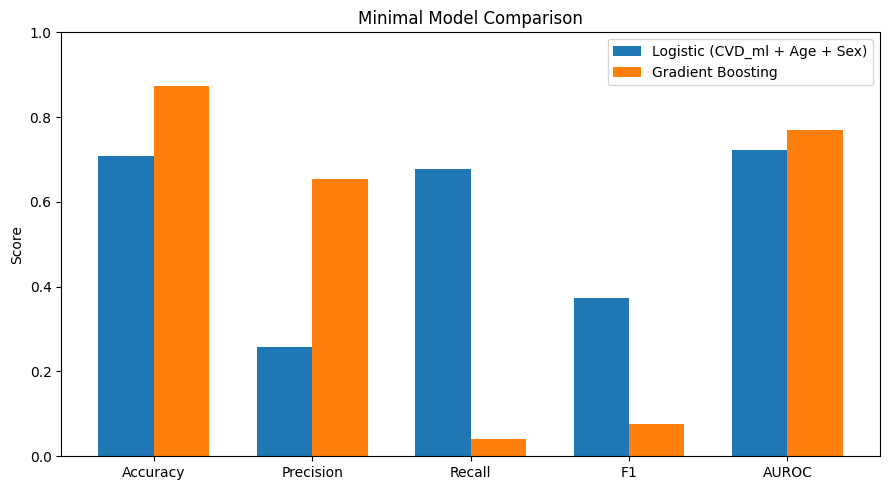

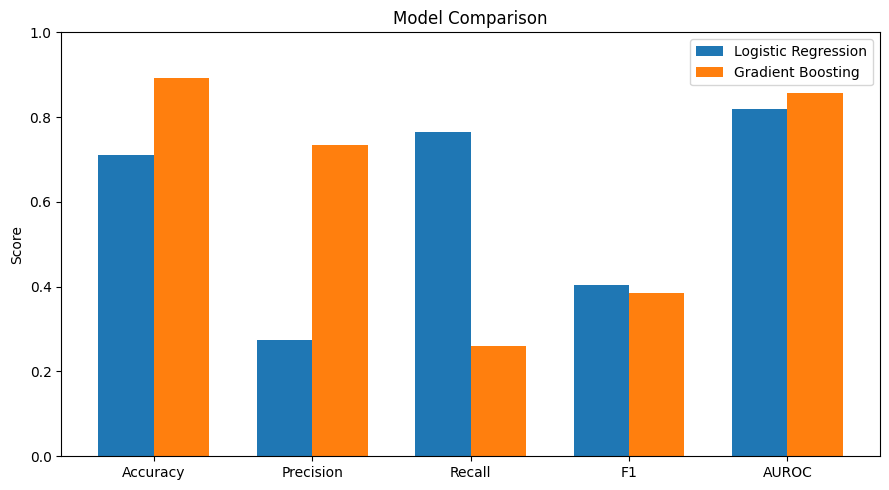

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


metrics = ["Accuracy", "Precision", "Recall", "F1", "AUROC"]
x = np.arange(len(metrics))
width = 0.35


log_min = [0.709, 0.257, 0.677, 0.373, 0.722]
gb_min  = [0.874, 0.653, 0.041, 0.077, 0.769]

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, log_min, width, label="Logistic (CVD_ml + Age + Sex)")
plt.bar(x + width/2, gb_min, width, label="Gradient Boosting")

plt.xticks(x, metrics)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Minimal Model Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("figure_minimal_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


log_exp = [0.710, 0.274, 0.764, 0.403, 0.818]
gb_exp  = [0.893, 0.735, 0.261, 0.385, 0.856]

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, log_exp, width, label="Logistic Regression")
plt.bar(x + width/2, gb_exp, width, label="Gradient Boosting")

plt.xticks(x, metrics)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("figure_expanded_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

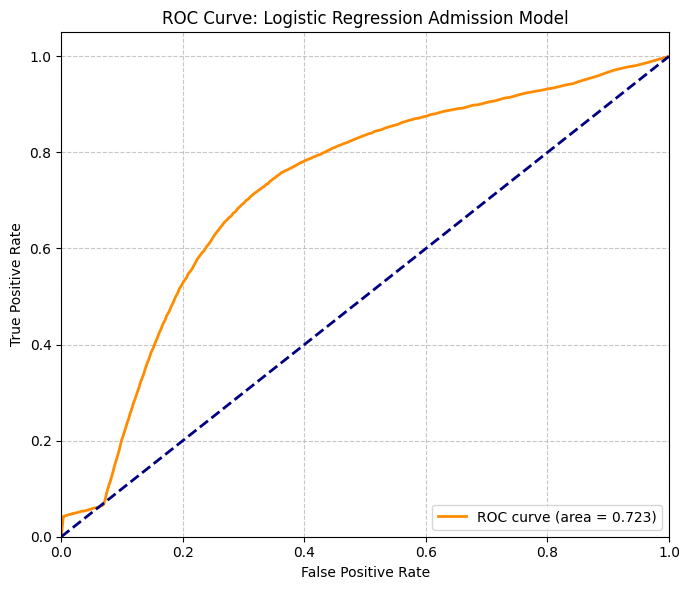

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


fpr, tpr, _ = roc_curve(y_test_adm_log, y_prob_adm_log)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Logistic Regression Admission Model')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('figure_roc_admission_logistic.png', dpi=300, bbox_inches='tight')
plt.show()